# Sequential CTTA: IDRiD → APTOS → Messidor (VisionFM)

Protocol:
1. Load VisionFM pretrained weights
2. Evaluate baseline on source domain (IDRiD)
3. Adapt to target domain (APTOS) - adaptation mode
4. Adapt to target domain (Messidor-2) - adaptation mode
5. Evaluate on ALL previous domains - TEST mode

This measures cumulative adaptation across 3 domains.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/sequential/cotta/idrid_aptos_messidor_visionfm.yaml')

print('Protocol: Sequential CTTA')
print(f'Source: {config.sequential.source_dataset.name}')
print(f'Targets: {[t.name for t in config.sequential.target_datasets]}')
print('Method:', config.ctta.method)
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Protocol: Sequential CTTA
Source: idrid
Targets: ['aptos2019', 'messidor2']
Method: cotta
Output: ./outputs/sequential_cotta/idrid_aptos_messidor_visionfm/
No HF token needed (VisionFM / Google Drive)


In [4]:
from src.evaluation.runner import SequentialCTTARunner

runner = SequentialCTTARunner(config)
results = runner.run()

2026-08-05 16:46:35,472 - src.evaluation.runner.sequential - INFO - Starting sequential CTTA: idrid -> aptos2019 -> messidor2
2026-08-05 16:46:35,474 - src.models.visionfm_download - INFO - VisionFM Fundus weights found at ./cache/visionfm/VFM_Fundus_weights.pth (cached)
2026-08-05 16:46:36,704 - src.models.visionfm - INFO - Loading VisionFM checkpoint from /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
2026-08-05 16:46:37,810 - src.models.visionfm - INFO - Extracted state_dict from 'teacher' key
2026-08-05 16:46:37,811 - src.models.visionfm - INFO - Stripped 'backbone.' prefix from 160 state dict keys
2026-08-05 16:46:37,882 - src.models.visionfm - INFO - VisionFM checkpoint cached in CPU RAM
2026-08-05 16:46:37,920 - src.models.visionfm - INFO - Frozen first 8 of 12 transformer blocks
2026-08-05 16:46:37,921 - src.models.visionfm - INFO - Feature normalization ENABLED in forward()
2026-08-05 16:46:38,285 - src.evaluation.runner.base - INFO - Loaded RETFound pretra

Adapting to idrid:   0%|          | 0/7 [00:00<?, ?it/s]

2026-08-05 16:47:15,795 - src.evaluation.runner.sequential - INFO -   Adapt step 0: loss=0.2300, kl=0.2472, conf_samples=11, teacher_max_prob=0.9158


Adapting to idrid:  14%|█▍        | 1/7 [00:08<00:50,  8.34s/it, acc=0.4375, adaptations=1]

2026-08-05 16:47:19,463 - src.evaluation.runner.sequential - INFO -   Adapt step 1: loss=0.0888, kl=0.1056, conf_samples=11, teacher_max_prob=0.9106


...

Adapting to messidor2:  95%|█████████▌| 21/22 [01:17<00:03,  3.59s/it, acc=0.2500, adaptations=21]

2026-08-05 16:51:19,992 - src.evaluation.runner.sequential - INFO -   Adapt step 21: loss=0.0919, kl=0.1417, conf_samples=6, teacher_max_prob=0.9229


Adapting to messidor2: 100%|██████████| 22/22 [01:20<00:00,  3.67s/it, acc=0.1538, adaptations=22]

2026-08-05 16:51:20,170 - src.evaluation.runner.sequential - INFO - Evaluating after adaptation on messidor2


2026-08-05 16:51:25,652 - src.evaluation.runner.sequential - INFO - Post-adaptation QWK: 0.1150
2026-08-05 16:51:25,654 - src.evaluation.runner.sequential - INFO - Adaptations: 22/22
2026-08-05 16:51:25,753 - src.evaluation.runner.sequential - INFO - 
Evaluating on all 3 seen domains after adapting to messidor2
2026-08-05 16:51:25,756 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on idrid (no adaptation)
2026-08-05 16:51:31,795 - src.evaluation.runner.sequential - INFO -   QWK on idrid: 0.4935
2026-08-05 16:51:31,799 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on aptos2019 (no adaptation)
2026-08-05 16:51:49,457 - src.evaluation.runner.sequential - INFO -   QWK on aptos2019: 0.5076
2026-08-05 16:51:54,975 - src.evaluation.runner.sequential - INFO -   QWK on messidor2: 0.1150
2026-08-05 16:51:54,978 - src.evaluation.runner.sequential - INFO - 
2026-08-05 16:51:54,980 - src.evaluation.runner.sequential - INFO - Sequential CTTA Complete - Summar

============== Sequential CTTA Results (CoTTA VisionFM) ==============

Source domain: idrid
  Baseline QWK:           0.4937
  Baseline Overall Acc:   36.89%

Target domains: aptos2019, messidor2

----------------------------------------------------------------------
After adapting to source idrid (7/7 batches):
  QWK:                  0.5024  (delta: +0.0088)
  Overall Acc:          37.86% (delta: +0.97pp)

----------------------------------------------------------------------
After adapting to aptos2019 (23/23 batches):
  Post-adaptation QWK on aptos2019: 0.5068
  Post-adaptation Acc on aptos2019: 18.85%
  Test on idrid:
    QWK: 0.4909  (delta vs baseline: -0.0028)
    Acc: 34.95% (delta vs baseline: -1.94pp)

----------------------------------------------------------------------
After adapting to messidor2 (22/22 batches):
  Post-adaptation QWK on messidor2: 0.1150
  Post-adaptation Acc on messidor2: 27.79%
  Test on idrid:
    QWK: 0.4935  (delta vs baseline: -0.0002)
    Acc: 35

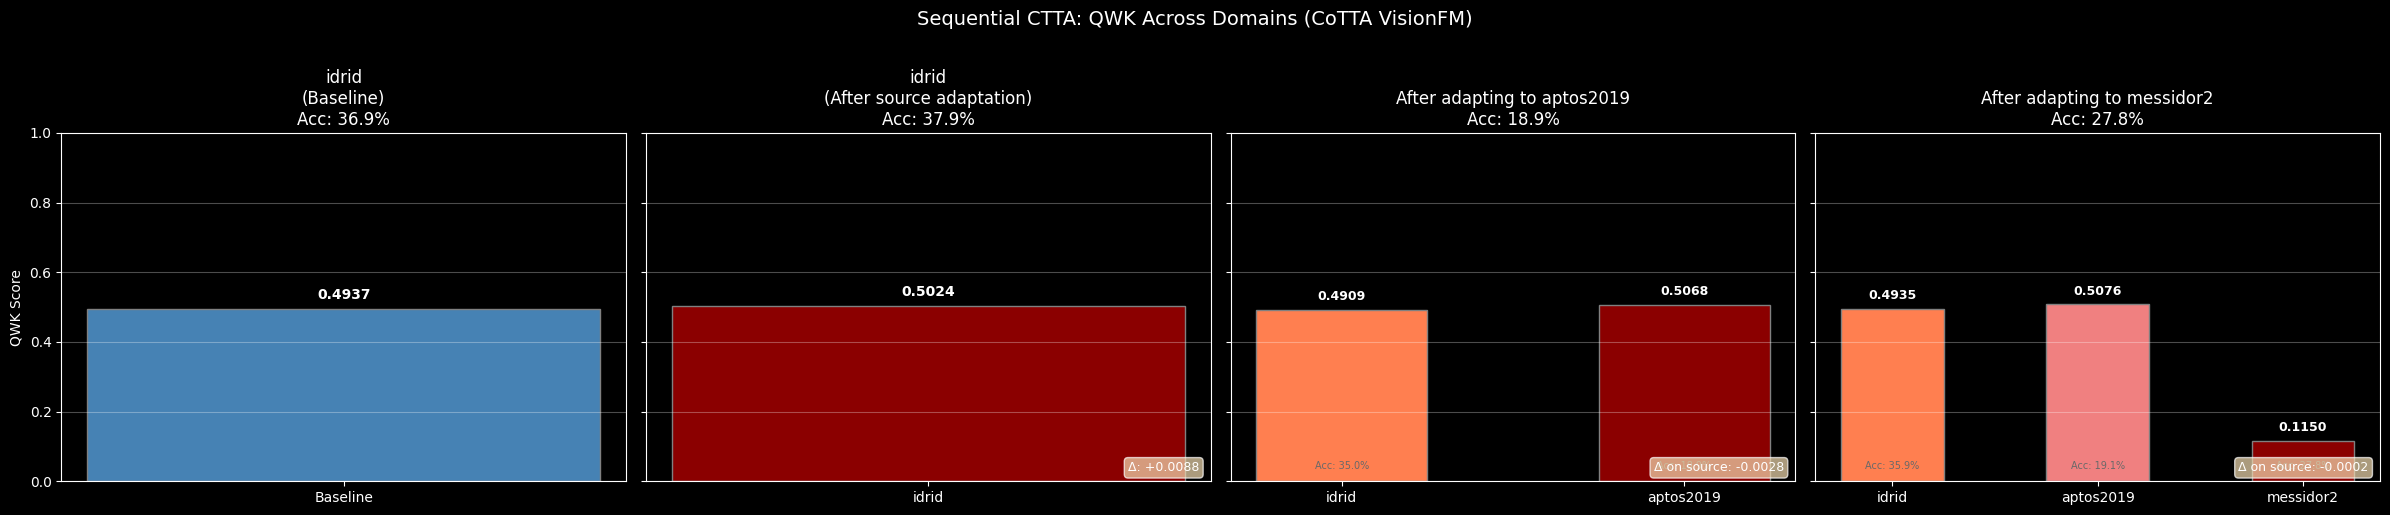

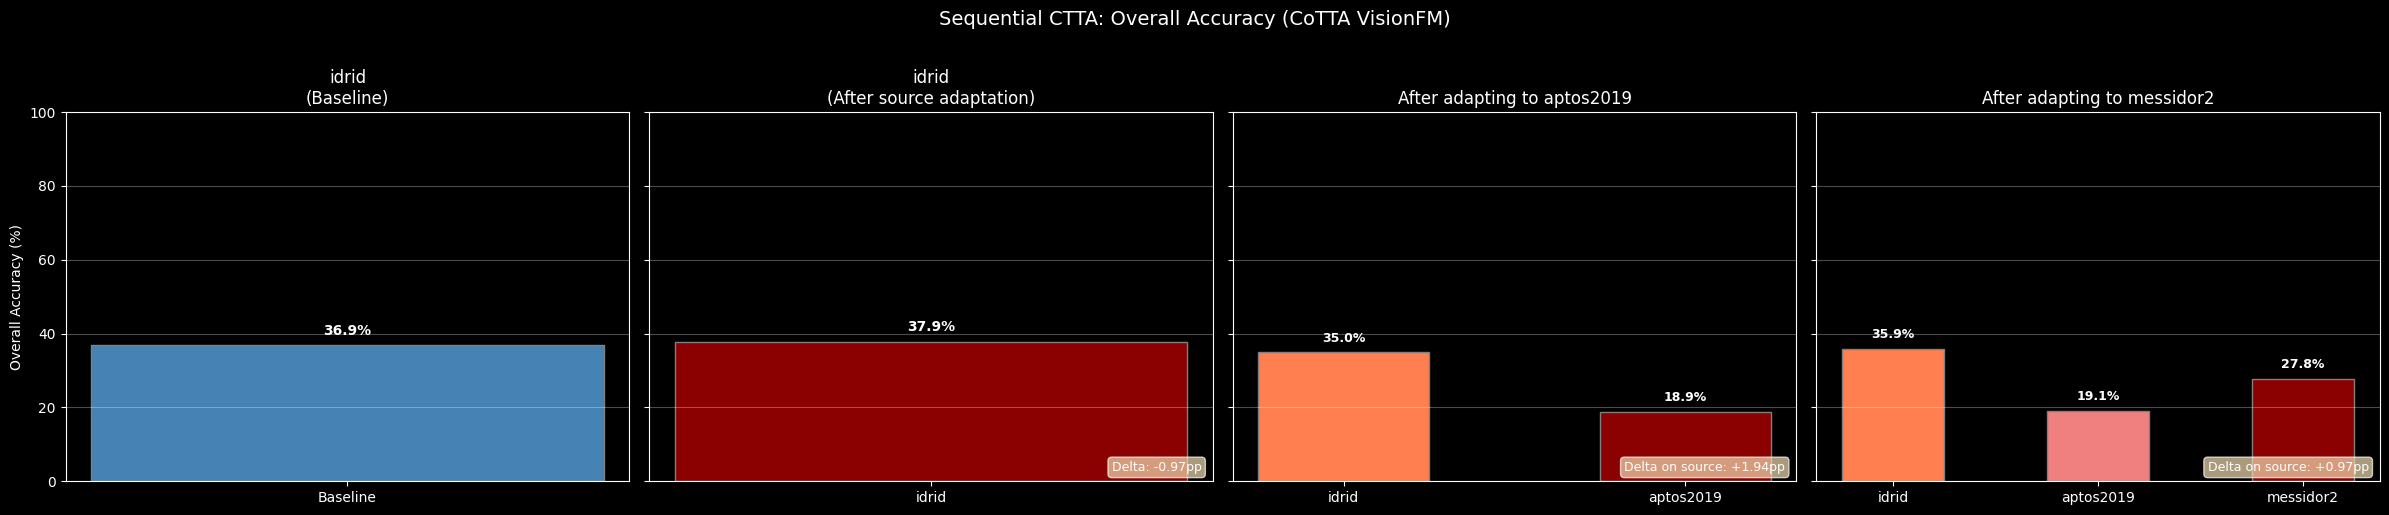

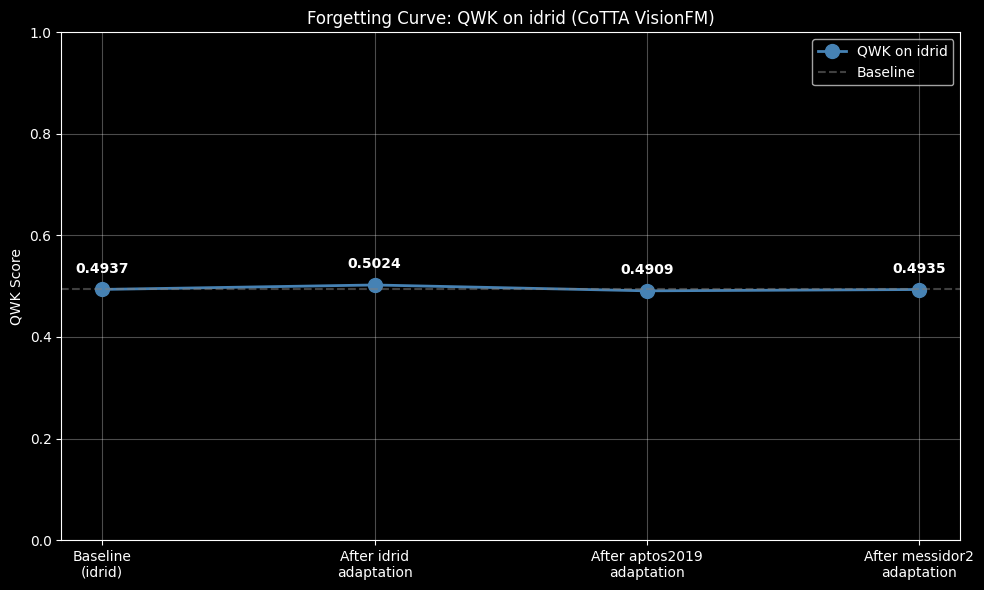

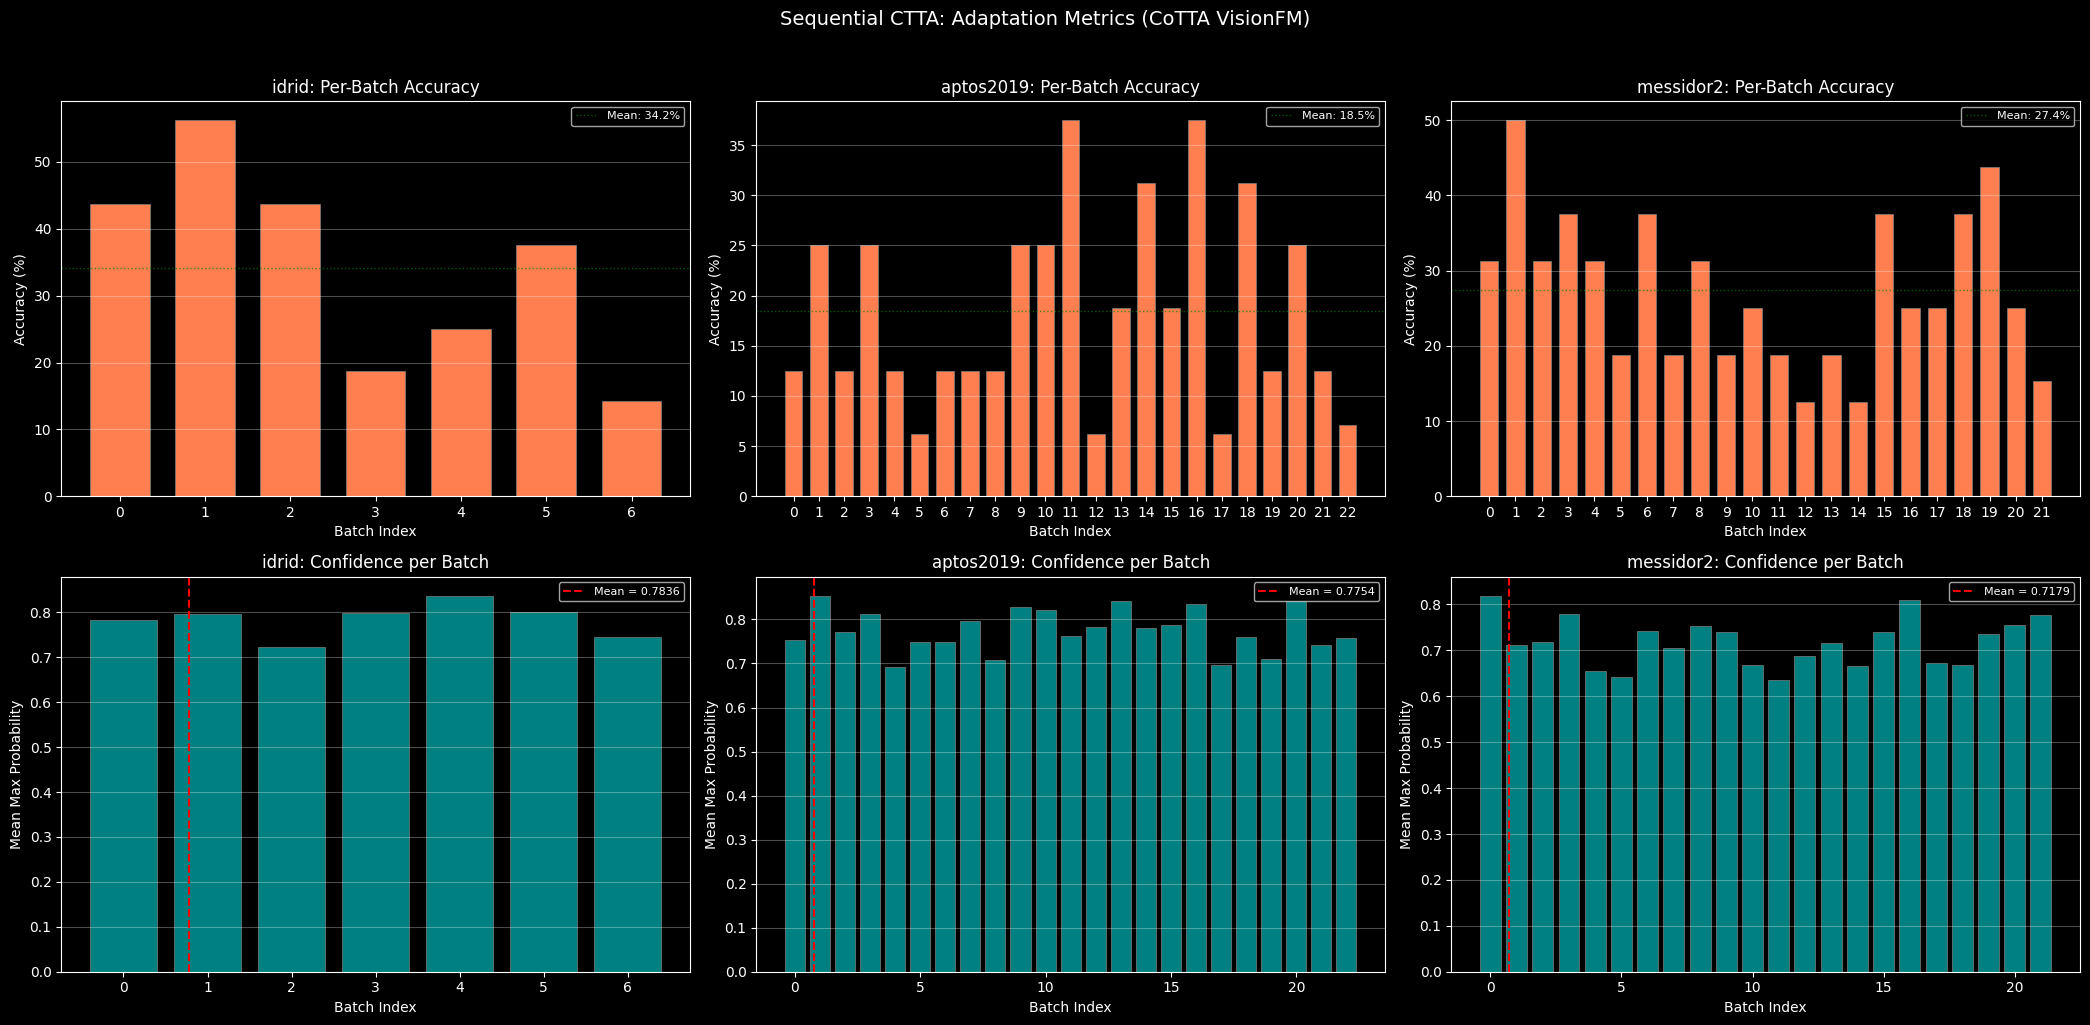

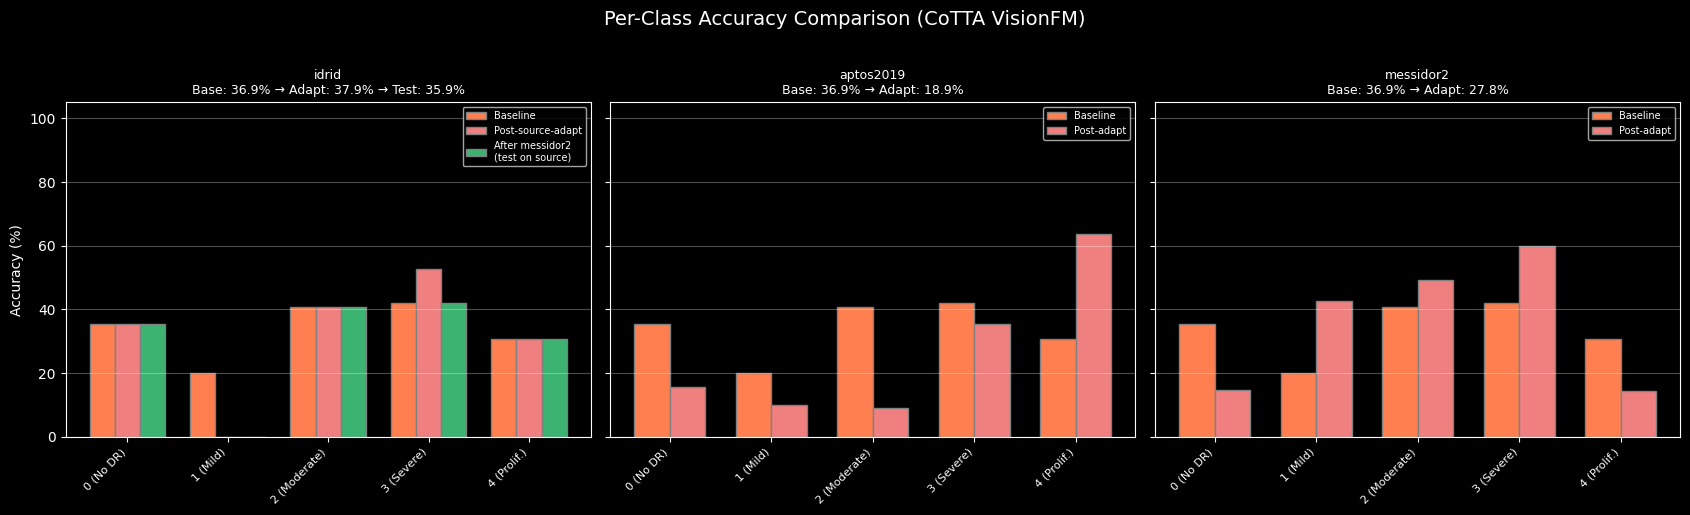

In [5]:
from pathlib import Path
from src.viz import (
    load_standalone_results,
    plot_sequential_qwk_comparison,
    plot_sequential_overall_accuracy,
    plot_sequential_forgetting,
    plot_sequential_adaptation_comparison,
    plot_sequential_per_class_accuracy,
    print_sequential_summary,
)

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

method_name = 'CoTTA DINOv2' if config.model.name == 'retfound' else 'CoTTA VisionFM'

print_sequential_summary(results, method_name=method_name)
plot_sequential_qwk_comparison(results, plots_dir, method_name=method_name)
plot_sequential_overall_accuracy(results, plots_dir, method_name=method_name)
plot_sequential_forgetting(results, plots_dir, method_name=method_name)
plot_sequential_adaptation_comparison(results, plots_dir, method_name=method_name)
plot_sequential_per_class_accuracy(results, plots_dir, method_name=method_name)